# Modular Weak Value Correlation: Per-Stabilizer ΔH Structure

## Motivation

The fan-out diagnostic shows that per-stabilizer ΔH spread predicts DBCI advantage.
But does the *internal structure* of the fan-out reflect code geometry?

Four analyses probe this:
1. **Pairwise ΔH curve correlations**: How similar are stabilizer curves within a code?
2. **CSS X/Z partition**: Do X-type and Z-type stabilizers show symmetric ΔH?
3. **Complement qubit mapping (Fez)**: On HaPPY, does each stabilizer's ΔH reflect
   the noise on the qubits it measures (entanglement wedge complement)?
4. **Cross-device validation (Marrakesh)**: Does the complement qubit mapping hold
   on a second device with a different noise profile? Combined p-value via Fisher's method.

## Data

Holographic codes only: HaPPY [[5,1,3]], Steane [[7,1,3]], Shor [[9,1,3]].
Fez data from existing hardware runs. Marrakesh data from cross-device notebook.
Zero additional QPU cost.

In [13]:
"""Cell 1: Imports, Setup, and ΔH Engine (VECTORIZED)"""

import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import os

%matplotlib inline

SEED = 42
np.random.seed(SEED)

from google.colab import drive
drive.mount('/content/drive')

OUTPUT_DIR = '.'
os.makedirs(OUTPUT_DIR, exist_ok=True)
DATA_DIR = '.'


def entropy_bits(p):
    p = np.asarray(p, dtype=np.float64)
    p = p[p > 0]
    return -np.sum(p * np.log2(p)) if len(p) > 0 else 0.0


def entropy_bits_batch(P):
    """Shannon entropy in bits for each column of P (n_hyp, n_shots)."""
    P = np.clip(P, 1e-30, None)
    return -np.sum(P * np.log2(P), axis=0)


def normalize_logits(logits):
    logits = np.asarray(logits, dtype=np.float64)
    logits -= np.max(logits)
    probs = np.exp(logits)
    Z = np.sum(probs)
    return probs / Z if Z > 1e-300 else np.ones_like(probs) / len(probs)


def normalize_logits_batch(logits):
    """Softmax over axis 0 for (n_hyp, n_shots) array."""
    logits = logits - logits.max(axis=0, keepdims=True)
    probs = np.exp(logits)
    Z = probs.sum(axis=0, keepdims=True)
    return np.where(Z > 1e-300, probs / Z, 1.0 / logits.shape[0])


def compute_delta_H(hw_data, error_labels, n_hyp, n_anc, beta, stab_subset=None):
    """Compute mean ΔH for holographic codes (2-fold CV, empirical P(s|h)).
    VECTORIZED: batch-processes all test shots at once."""
    n_sub = len(stab_subset) if stab_subset is not None else n_anc
    n_syn = 2 ** n_sub
    powers = 2 ** np.arange(n_sub - 1, -1, -1)

    p_no_err = 1.0 / (1.0 + (n_hyp - 1) * np.exp(-beta))
    log_prior = np.zeros(n_hyp)
    log_prior[0] = np.log(max(p_no_err, 1e-10))
    log_prior[1:] = np.log(max((1 - p_no_err) / (n_hyp - 1), 1e-10))
    log_uniform = np.zeros(n_hyp)

    all_dH = []
    for state in ['0', '1']:
        sd = {}
        for idx, lbl in enumerate(error_labels):
            key = f'L{state}_{lbl}'
            if key in hw_data:
                syn = hw_data[key]['syndrome']
                if stab_subset is not None:
                    syn = syn[:, stab_subset]
                sd[idx] = syn
        if not sd:
            continue
        n_shots = len(list(sd.values())[0])
        mid = n_shots // 2
        for tst, trn in [(slice(0, mid), slice(mid, None)),
                         (slice(mid, None), slice(0, mid))]:
            # Build log-likelihood table
            log_lik = np.full((n_hyp, n_syn), np.log(1.0 / n_syn))
            for h in sd:
                keys = (sd[h][trn] * powers).sum(1).astype(int)
                counts = np.bincount(keys, minlength=n_syn).astype(float)
                log_lik[h] = np.log((counts + 1) / (counts.sum() + n_syn))

            # Batch: gather all test syndrome keys across hypotheses
            test_keys = np.concatenate(
                [(sd[h][tst] * powers).sum(1).astype(int) for h in sd])

            # Vectorized ΔH computation
            ll = log_lik[:, test_keys]          # (n_hyp, n_test_shots)
            p_fwd = normalize_logits_batch(ll + log_uniform[:, None])
            p_dbci = normalize_logits_batch(ll + log_prior[:, None])
            dH = entropy_bits_batch(p_fwd) - entropy_bits_batch(p_dbci)
            all_dH.append(dH)

    all_dH = np.concatenate(all_dH)
    return np.mean(all_dH), np.std(all_dH) / np.sqrt(len(all_dH)), all_dH


print('Imports and ΔH engine OK (vectorized)')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Imports and ΔH engine OK (vectorized)


In [14]:
"""Cell 2: Stabilizer Definitions and Structural Maps"""

codes = {}

# HaPPY [[5,1,3]] — non-CSS, perfect tensor
codes['HaPPY'] = {
    'stabs': ['XZZXI', 'IXZZX', 'XIXZZ', 'ZXIXZ'],
    'n': 5,
    'n_hyp': 16,
    'css_type': None,
}

# Steane [[7,1,3]] — CSS code
codes['Steane'] = {
    'stabs': ['IIIXXXX', 'IXXIIXX', 'XIXIXIX',
              'IIIZZZZ', 'IZZIIZZ', 'ZIZIZIZ'],
    'n': 7,
    'n_hyp': 22,
    'css_type': [0, 0, 0, 1, 1, 1],  # 0=X-type, 1=Z-type
}

# Shor [[9,1,3]] — CSS code, block structure
codes['Shor'] = {
    'stabs': ['ZZIIIIIII', 'IZZIIIIII', 'IIIZZIIII', 'IIIIZZIII',
              'IIIIIIZZI', 'IIIIIIIZZ', 'XXXXXXIII', 'IIIXXXXXX'],
    'n': 9,
    'n_hyp': 22,
    'css_type': [1, 1, 1, 1, 1, 1, 0, 0],  # S0-S5 Z-type, S6-S7 X-type
}


def stab_support(s):
    return {i for i, c in enumerate(s) if c != 'I'}


def stab_pauli_map(s):
    return {i: c for i, c in enumerate(s) if c != 'I'}


for name, code in codes.items():
    n_stab = len(code['stabs'])
    code['n_stab'] = n_stab
    code['support'] = [stab_support(s) for s in code['stabs']]
    code['complement'] = [set(range(code['n'])) - sup for sup in code['support']]
    code['pauli_map'] = [stab_pauli_map(s) for s in code['stabs']]

    # Pairwise qubit overlap
    overlap = np.zeros((n_stab, n_stab), dtype=int)
    for i in range(n_stab):
        for j in range(n_stab):
            overlap[i, j] = len(code['support'][i] & code['support'][j])
    code['overlap'] = overlap

    print(f'\n{name} ({n_stab} stabilizers):')
    for si, s in enumerate(code['stabs']):
        comp = sorted(code['complement'][si])
        print(f'  S{si}: {s}  support={sorted(code["support"][si])}  '
              f'complement={comp}')
    print(f'  Overlap matrix:\n{overlap}')

print('\nStructural maps complete.')


HaPPY (4 stabilizers):
  S0: XZZXI  support=[0, 1, 2, 3]  complement=[4]
  S1: IXZZX  support=[1, 2, 3, 4]  complement=[0]
  S2: XIXZZ  support=[0, 2, 3, 4]  complement=[1]
  S3: ZXIXZ  support=[0, 1, 3, 4]  complement=[2]
  Overlap matrix:
[[4 3 3 3]
 [3 4 3 3]
 [3 3 4 3]
 [3 3 3 4]]

Steane (6 stabilizers):
  S0: IIIXXXX  support=[3, 4, 5, 6]  complement=[0, 1, 2]
  S1: IXXIIXX  support=[1, 2, 5, 6]  complement=[0, 3, 4]
  S2: XIXIXIX  support=[0, 2, 4, 6]  complement=[1, 3, 5]
  S3: IIIZZZZ  support=[3, 4, 5, 6]  complement=[0, 1, 2]
  S4: IZZIIZZ  support=[1, 2, 5, 6]  complement=[0, 3, 4]
  S5: ZIZIZIZ  support=[0, 2, 4, 6]  complement=[1, 3, 5]
  Overlap matrix:
[[4 2 2 4 2 2]
 [2 4 2 2 4 2]
 [2 2 4 2 2 4]
 [4 2 2 4 2 2]
 [2 4 2 2 4 2]
 [2 2 4 2 2 4]]

Shor (8 stabilizers):
  S0: ZZIIIIIII  support=[0, 1]  complement=[2, 3, 4, 5, 6, 7, 8]
  S1: IZZIIIIII  support=[1, 2]  complement=[0, 3, 4, 5, 6, 7, 8]
  S2: IIIZZIIII  support=[3, 4]  complement=[0, 1, 2, 5, 6, 7, 8]
  S3: IIII

In [15]:
"""Cell 3: Load Data + Compute/Load Per-Stabilizer \u0394H(\u03b2)"""


def make_labels(n):
    labels = ['I']
    for q in range(n):
        for p in 'XYZ':
            labels.append(f'{p}{q}')
    return labels


def make_shor_labels():
    labels = ['I']
    for q in range(9):
        for p in 'XY':
            labels.append(f'{p}{q}')
    for q in [0, 3, 6]:
        labels.append(f'Z{q}')
    return labels


def load_holographic_npz(path, error_labels):
    raw = np.load(path)
    circuit_labels = [f'L{s}_{l}' for s in [0, 1] for l in error_labels]
    hw = {}
    for i, cl in enumerate(circuit_labels):
        ks, ko = f'pub{i}_syn', f'pub{i}_out'
        if ks in raw:
            hw[cl] = {'syndrome': raw[ks].astype(int),
                      'data': raw[ko].astype(int)}
    return hw


# --- Load raw hardware data (needed for syndrome error analysis) ---
label_map = {
    'HaPPY': make_labels(5),
    'Steane': make_labels(7),
    'Shor': make_shor_labels(),
}
npz_map = {
    'HaPPY': 'happy_553.npz',
    'Steane': 'steane_713.npz',
    'Shor': 'shor_913.npz',
}

hw_data = {}
for name in codes:
    hw_data[name] = load_holographic_npz(
        os.path.join(DATA_DIR, npz_map[name]), label_map[name])
    n_circ = len(hw_data[name])
    n_shots = hw_data[name]['L0_I']['syndrome'].shape[0]
    print(f'{name}: {n_circ} circuits, {n_shots} shots')

# --- Try loading fan-out diagnostic results ---
beta_values = np.array([0, 0.5, 1.0, 2.0, 3.0, 5.0, 8.0, 12.0, 20.0])
per_stab_dH = {}

fanout_path = os.path.join(OUTPUT_DIR, 'fanout_diagnostic_results.npz')
if os.path.exists(fanout_path):
    print(f'\nLoading fan-out results from {fanout_path}...')
    fr = np.load(fanout_path)
    per_stab_dH['HaPPY'] = fr['happy_means']
    per_stab_dH['Steane'] = fr['steane_means']
    per_stab_dH['Shor'] = fr['shor_means']
    # Use saved beta values if available
    if 'beta_values' in fr:
        beta_values = fr['beta_values']
    print(f'Loaded. Shape: HaPPY {per_stab_dH["HaPPY"].shape}, '
          f'Steane {per_stab_dH["Steane"].shape}, '
          f'Shor {per_stab_dH["Shor"].shape}')
else:
    print(f'\nFan-out results not found at {fanout_path}')
    print('Computing per-stabilizer \u0394H from raw data (~15-20 min)...')
    for name in codes:
        c = codes[name]
        n_stab = c['n_stab']
        means = np.zeros((n_stab, len(beta_values)))
        for si in range(n_stab):
            for bi, beta in enumerate(beta_values):
                m, _, _ = compute_delta_H(
                    hw_data[name], label_map[name],
                    c['n_hyp'], n_stab, beta, stab_subset=[si])
                means[si, bi] = m
            print(f'  {name} S{si}: done')
        per_stab_dH[name] = means
        sat = means[:, -1]
        print(f'  {name}: spread={sat.max()-sat.min():.4f} bits')

print('\nPer-stabilizer \u0394H data ready.')

In [16]:
"""Cell 4: Analysis 1 \u2014 Pairwise \u0394H(\u03b2) Curve Correlations

For each code, compute Pearson correlation between every pair of
stabilizer \u0394H(\u03b2) curves. High mean correlation = bundle (curves
move together). Low mean correlation = fan-out (curves diverge).
"""

print('=' * 65)
print('PAIRWISE \u0394H(\u03b2) CURVE CORRELATIONS')
print('=' * 65)

corr_matrices = {}
mean_corrs = {}

for name in codes:
    dH = per_stab_dH[name]  # (n_stab, n_beta)
    n_stab = dH.shape[0]

    # Pairwise Pearson correlation of \u0394H(\u03b2) curves
    corr = np.corrcoef(dH)  # (n_stab, n_stab)
    corr_matrices[name] = corr

    # Mean off-diagonal correlation
    mask = ~np.eye(n_stab, dtype=bool)
    mean_corr = corr[mask].mean()
    min_corr = corr[mask].min()
    mean_corrs[name] = mean_corr

    print(f'\n{name} ({n_stab} stabilizers):')
    print(f'  Mean pairwise r: {mean_corr:.4f}')
    print(f'  Min pairwise r:  {min_corr:.4f}')
    print(f'  Correlation matrix:')
    header = '       ' + '  '.join(f'  S{j}   ' for j in range(n_stab))
    print(header)
    for i in range(n_stab):
        row = '  '.join(f'{corr[i,j]:+.4f}' for j in range(n_stab))
        print(f'    S{i}: {row}')

print(f'\n--- Summary ---')
print(f'{"Code":<10} {"Mean r":>8} {"Min r":>8} {"Pattern":>20}')
print('-' * 50)
for name in codes:
    pattern = ('Bundle' if mean_corrs[name] > 0.999
               else 'Fan-out' if mean_corrs[name] < 0.99
               else 'Intermediate')
    mask = ~np.eye(codes[name]['n_stab'], dtype=bool)
    min_r = corr_matrices[name][mask].min()
    print(f'{name:<10} {mean_corrs[name]:>8.4f} {min_r:>8.4f} {pattern:>20}')

PAIRWISE ΔH(β) CURVE CORRELATIONS

HaPPY (4 stabilizers):
  Mean pairwise r: 0.9997
  Min pairwise r:  0.9992
  Correlation matrix:
         S0       S1       S2       S3   
    S0: +1.0000  +0.9996  +0.9992  +0.9993
    S1: +0.9996  +1.0000  +0.9999  +0.9999
    S2: +0.9992  +0.9999  +1.0000  +1.0000
    S3: +0.9993  +0.9999  +1.0000  +1.0000

Steane (6 stabilizers):
  Mean pairwise r: 1.0000
  Min pairwise r:  1.0000
  Correlation matrix:
         S0       S1       S2       S3       S4       S5   
    S0: +1.0000  +1.0000  +1.0000  +1.0000  +1.0000  +1.0000
    S1: +1.0000  +1.0000  +1.0000  +1.0000  +1.0000  +1.0000
    S2: +1.0000  +1.0000  +1.0000  +1.0000  +1.0000  +1.0000
    S3: +1.0000  +1.0000  +1.0000  +1.0000  +1.0000  +1.0000
    S4: +1.0000  +1.0000  +1.0000  +1.0000  +1.0000  +1.0000
    S5: +1.0000  +1.0000  +1.0000  +1.0000  +1.0000  +1.0000

Shor (8 stabilizers):
  Mean pairwise r: 1.0000
  Min pairwise r:  1.0000
  Correlation matrix:
         S0       S1       S2   

In [17]:
"""Cell 5: Analysis 2 \u2014 CSS X/Z Partition Test

On CSS codes, X-type and Z-type stabilizers have identical qubit support
but detect complementary error types. Under symmetric noise, their
per-stabilizer \u0394H should be identical.

Steane: S0-S2 (X-type) paired with S3-S5 (Z-type), same support per pair.
Shor: S0-S5 (Z-type, within-block) vs S6-S7 (X-type, cross-block).
"""

print('=' * 65)
print('CSS X/Z PARTITION TEST')
print('=' * 65)

css_results = {}

for name in ['Steane', 'Shor']:
    c = codes[name]
    dH = per_stab_dH[name]
    css = np.array(c['css_type'])
    sat = dH[:, -1]

    x_idx = np.where(css == 0)[0]
    z_idx = np.where(css == 1)[0]
    x_mean, z_mean = sat[x_idx].mean(), sat[z_idx].mean()
    x_std, z_std = sat[x_idx].std(), sat[z_idx].std()

    print(f'\n{name}:')
    print(f'  X-type ({len(x_idx)}): mean \u0394H = {x_mean:.4f} \u00b1 {x_std:.4f}')
    print(f'  Z-type ({len(z_idx)}): mean \u0394H = {z_mean:.4f} \u00b1 {z_std:.4f}')
    print(f'  |X - Z| = {abs(x_mean - z_mean):.4f} bits')

    for si in range(len(c['stabs'])):
        css_label = 'X' if css[si] == 0 else 'Z'
        print(f'    S{si} ({css_label}): \u0394H_sat = {sat[si]:.4f}')

    # Steane: paired support test
    if name == 'Steane':
        print(f'\n  Paired support test (X/Z pairs with identical qubit support):')
        pairs = [(0, 3), (1, 4), (2, 5)]
        diffs = []
        for xi, zi in pairs:
            diff = abs(sat[xi] - sat[zi])
            diffs.append(diff)
            print(f'    S{xi}(X) vs S{zi}(Z): {sat[xi]:.4f} vs {sat[zi]:.4f}, '
                  f'|diff| = {diff:.4f} bits')
        css_results['Steane_pair_diffs'] = diffs
        print(f'    Mean |diff| = {np.mean(diffs):.4f} bits '
              f'(0 = perfectly symmetric noise)')

    # Shor: block structure
    if name == 'Shor':
        print(f'\n  Block structure:')
        # Z-type: S0/S1 = block 0, S2/S3 = block 1, S4/S5 = block 2
        blocks = [(0, 1), (2, 3), (4, 5)]
        for bi, (s1, s2) in enumerate(blocks):
            print(f'    Block {bi} (S{s1},S{s2}): '
                  f'{sat[s1]:.4f}, {sat[s2]:.4f}  '
                  f'|diff| = {abs(sat[s1]-sat[s2]):.4f}')
        print(f'    Cross-block X-type (S6,S7): {sat[6]:.4f}, {sat[7]:.4f}')
        # Within-block vs cross-block
        z_range = sat[z_idx].max() - sat[z_idx].min()
        x_range = sat[x_idx].max() - sat[x_idx].min()
        print(f'    Z-type range: {z_range:.4f}  X-type range: {x_range:.4f}')
        css_results['Shor_z_range'] = z_range
        css_results['Shor_x_range'] = x_range

CSS X/Z PARTITION TEST

Steane:
  X-type (3): mean ΔH = 4.4555 ± 0.0030
  Z-type (3): mean ΔH = 4.4575 ± 0.0015
  |X - Z| = 0.0020 bits
    S0 (X): ΔH_sat = 4.4514
    S1 (X): ΔH_sat = 4.4564
    S2 (X): ΔH_sat = 4.4586
    S3 (Z): ΔH_sat = 4.4580
    S4 (Z): ΔH_sat = 4.4555
    S5 (Z): ΔH_sat = 4.4590

  Paired support test (X/Z pairs with identical qubit support):
    S0(X) vs S3(Z): 4.4514 vs 4.4580, |diff| = 0.0066 bits
    S1(X) vs S4(Z): 4.4564 vs 4.4555, |diff| = 0.0009 bits
    S2(X) vs S5(Z): 4.4586 vs 4.4590, |diff| = 0.0004 bits
    Mean |diff| = 0.0026 bits (0 = perfectly symmetric noise)

Shor:
  X-type (2): mean ΔH = 4.4593 ± 0.0000
  Z-type (6): mean ΔH = 4.4225 ± 0.0517
  |X - Z| = 0.0367 bits
    S0 (Z): ΔH_sat = 4.3269
    S1 (Z): ΔH_sat = 4.3782
    S2 (Z): ΔH_sat = 4.4578
    S3 (Z): ΔH_sat = 4.4570
    S4 (Z): ΔH_sat = 4.4577
    S5 (Z): ΔH_sat = 4.4577
    S6 (X): ΔH_sat = 4.4593
    S7 (X): ΔH_sat = 4.4593

  Block structure:
    Block 0 (S0,S1): 4.3269, 4.3782  

In [18]:
"""Cell 6: Analysis 3 \u2014 Complement Qubit \u2192 \u0394H Mapping (HaPPY)

On [[5,1,3]], each stabilizer Si acts on 4 of 5 qubits, missing one (qi).
Si's syndrome reliability depends on noise on its 4 support qubits.
Since all pairs share 3 qubits, the \u0394H difference between stabilizers
is driven by their unique complement qubit.

Prediction: \u0394H(Si) correlates with Si's syndrome error rate.
The stabilizer missing the noisiest qubit has the lowest \u0394H
(its support qubits are cleaner on average).
"""

print('=' * 65)
print('COMPLEMENT QUBIT \u2192 \u0394H MAPPING (HaPPY [[5,1,3]])')
print('=' * 65)

c = codes['HaPPY']
hw = hw_data['HaPPY']
n_stab_h = c['n_stab']
sat_happy = per_stab_dH['HaPPY'][:, -1]

# --- Per-stabilizer syndrome error rate from identity circuits ---
# For L0_I and L1_I, expected syndrome = all zeros.
# Syndrome error rate = fraction of shots where bit is 1.
syn_err_rates = np.zeros(n_stab_h)
n_id_shots = 0
for state in ['0', '1']:
    key = f'L{state}_I'
    if key in hw:
        syn = hw[key]['syndrome']
        syn_err_rates += syn.mean(axis=0)
        n_id_shots += syn.shape[0]
syn_err_rates /= 2  # average over both logical states

print(f'\nPer-stabilizer metrics (identity circuit, {n_id_shots} total shots):')
print(f'{"Stab":<6} {"Complement":<12} {"Syn Error":>10} {"\u0394H_sat":>10}')
print('-' * 42)
for si in range(n_stab_h):
    comp = sorted(c['complement'][si])
    print(f'S{si:<5} q{comp[0]:<11} {syn_err_rates[si]:>10.4f} '
          f'{sat_happy[si]:>10.4f}')

# Correlation: syndrome error rate vs \u0394H at saturation
rho_syn, p_syn = stats.spearmanr(syn_err_rates, sat_happy)
r_syn, pr_syn = stats.pearsonr(syn_err_rates, sat_happy)
print(f'\nSyndrome error rate vs \u0394H_sat:')
print(f'  Spearman \u03c1 = {rho_syn:.3f} (p = {p_syn:.4f})')
print(f'  Pearson  r = {r_syn:.3f} (p = {pr_syn:.4f})')

# Rank analysis
dH_rank = np.argsort(sat_happy)[::-1]  # highest \u0394H first
syn_rank = np.argsort(syn_err_rates)[::-1]
print(f'\n\u0394H ranking (highest first):      {["S" + str(i) for i in dH_rank]}')
print(f'Syn error ranking (highest first): {["S" + str(i) for i in syn_rank]}')
rank_match = all(dH_rank == syn_rank)
print(f'Perfect rank match: {rank_match}')

# Complement qubit interpretation
print(f'\nInterpretation:')
hi_si = dH_rank[0]
lo_si = dH_rank[-1]
hi_q = sorted(c['complement'][hi_si])[0]
lo_q = sorted(c['complement'][lo_si])[0]
print(f'  Highest \u0394H: S{hi_si} (misses q{hi_q})')
print(f'    \u2192 q{hi_q} is the LEAST noisy qubit (S{hi_si}\'s other 4 are noisier)')
print(f'  Lowest \u0394H:  S{lo_si} (misses q{lo_q})')
print(f'    \u2192 q{lo_q} is the MOST noisy qubit (S{lo_si}\'s other 4 are cleaner)')

# Also compute syndrome error rates for Steane and Shor
syn_err_all = {}
for name in codes:
    hw_c = hw_data[name]
    n_s = codes[name]['n_stab']
    rates = np.zeros(n_s)
    for state in ['0', '1']:
        key = f'L{state}_I'
        if key in hw_c:
            rates += hw_c[key]['syndrome'].mean(axis=0)
    syn_err_all[name] = rates / 2

# Steane: do paired stabilizers have similar syndrome error rates?
print(f'\n--- Steane syndrome error rates ---')
steane_syn = syn_err_all['Steane']
for si in range(6):
    css_l = 'X' if codes['Steane']['css_type'][si] == 0 else 'Z'
    print(f'  S{si} ({css_l}): {steane_syn[si]:.4f}')
print(f'  X/Z pair diffs: '
      f'{abs(steane_syn[0]-steane_syn[3]):.4f}, '
      f'{abs(steane_syn[1]-steane_syn[4]):.4f}, '
      f'{abs(steane_syn[2]-steane_syn[5]):.4f}')

COMPLEMENT QUBIT → ΔH MAPPING (HaPPY [[5,1,3]])

Per-stabilizer metrics (identity circuit, 16384 total shots):
Stab   Complement    Syn Error     ΔH_sat
------------------------------------------
S0     q4               0.2159     3.7518
S1     q0               0.2980     3.9010
S2     q1               0.6292     3.9563
S3     q2               0.3600     3.9442

Syndrome error rate vs ΔH_sat:
  Spearman ρ = 1.000 (p = 0.0000)
  Pearson  r = 0.736 (p = 0.2637)

ΔH ranking (highest first):      ['S2', 'S3', 'S1', 'S0']
Syn error ranking (highest first): ['S2', 'S3', 'S1', 'S0']
Perfect rank match: True

Interpretation:
  Highest ΔH: S2 (misses q1)
    → q1 is the LEAST noisy qubit (S2's other 4 are noisier)
  Lowest ΔH:  S0 (misses q4)
    → q4 is the MOST noisy qubit (S0's other 4 are cleaner)

--- Steane syndrome error rates ---
  S0 (X): 0.4416
  S1 (X): 0.4705
  S2 (X): 0.4818
  S3 (Z): 0.4790
  S4 (Z): 0.4599
  S5 (Z): 0.4918
  X/Z pair diffs: 0.0374, 0.0106, 0.0101


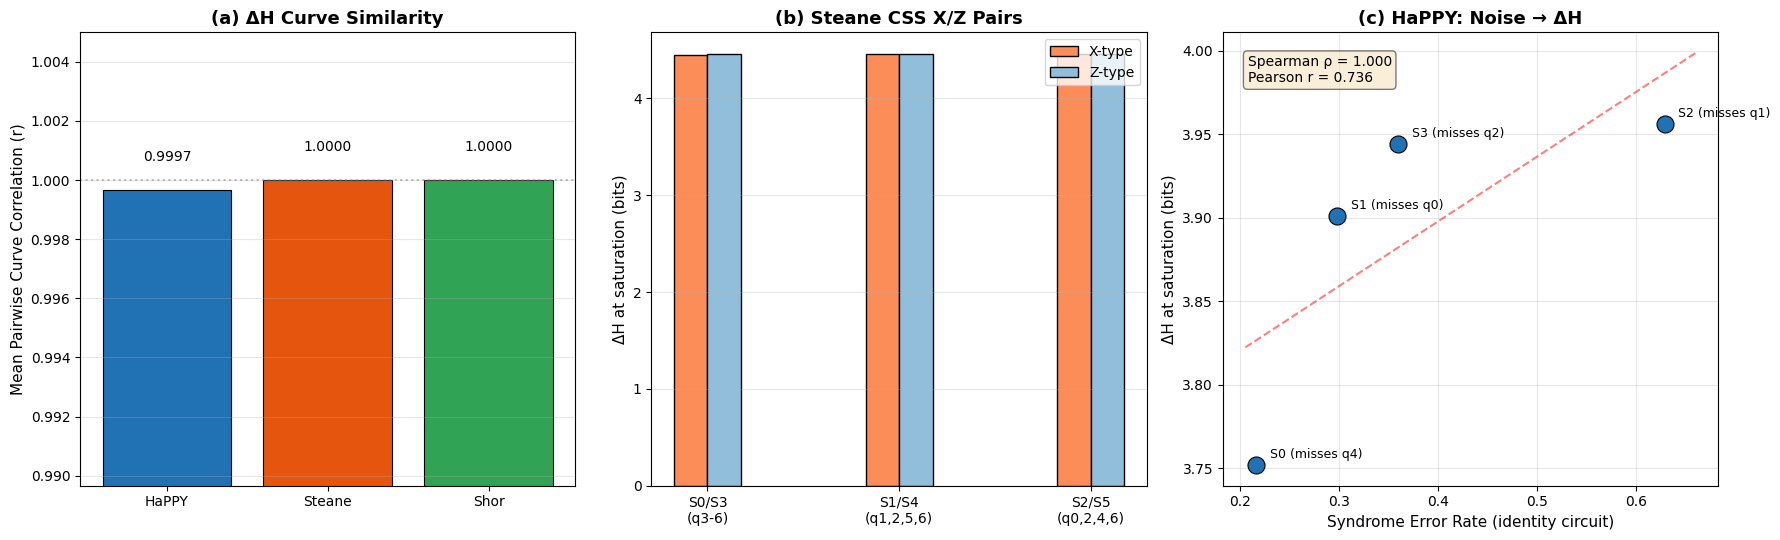

In [19]:
"""Cell 7: Summary Figure (3 panels)"""

fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))

# === Panel (a): Mean pairwise correlation bar chart ===
ax = axes[0]
names_list = ['HaPPY', 'Steane', 'Shor']
mean_r = [mean_corrs[n] for n in names_list]
colors = ['#2171b5', '#e6550d', '#31a354']
bars = ax.bar(names_list, mean_r, color=colors,
              edgecolor='black', linewidth=0.8)
ax.set_ylabel('Mean Pairwise Curve Correlation (r)', fontsize=11)
ax.set_title('(a) \u0394H Curve Similarity', fontsize=13, fontweight='bold')

# Auto-scale y-axis to show differences
y_min = min(mean_r) - 0.01
ax.set_ylim(max(0.9, y_min), 1.005)
ax.axhline(1.0, color='gray', ls=':', alpha=0.5)
for bar, val in zip(bars, mean_r):
    ax.text(bar.get_x() + bar.get_width() / 2, val + 0.001,
            f'{val:.4f}', ha='center', fontsize=10)
ax.grid(True, alpha=0.3, axis='y')

# === Panel (b): Steane CSS paired bar chart ===
ax = axes[1]
steane_sat = per_stab_dH['Steane'][:, -1]
x_bars = steane_sat[[0, 1, 2]]
z_bars = steane_sat[[3, 4, 5]]
x_pos = np.arange(3) * 2
width = 0.35
ax.bar(x_pos - width / 2, x_bars, width, label='X-type',
       color='#fc8d59', edgecolor='black')
ax.bar(x_pos + width / 2, z_bars, width, label='Z-type',
       color='#91bfdb', edgecolor='black')
ax.set_xticks(x_pos)
ax.set_xticklabels(['S0/S3\n(q3-6)', 'S1/S4\n(q1,2,5,6)',
                     'S2/S5\n(q0,2,4,6)'])
ax.set_ylabel('\u0394H at saturation (bits)', fontsize=11)
ax.set_title('(b) Steane CSS X/Z Pairs', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3, axis='y')

# === Panel (c): HaPPY syndrome error vs \u0394H scatter ===
ax = axes[2]
ax.scatter(syn_err_rates, sat_happy, s=150, c='#2171b5',
           edgecolors='black', linewidths=0.8, zorder=5)
for si in range(n_stab_h):
    comp_q = sorted(c['complement'][si])[0]
    ax.annotate(f'S{si} (misses q{comp_q})',
                (syn_err_rates[si], sat_happy[si]),
                textcoords='offset points', xytext=(10, 5), fontsize=9)
# Fit line
z = np.polyfit(syn_err_rates, sat_happy, 1)
x_fit = np.linspace(syn_err_rates.min() * 0.95,
                     syn_err_rates.max() * 1.05, 50)
ax.plot(x_fit, np.polyval(z, x_fit), 'r--', alpha=0.5)
ax.text(0.05, 0.95, f'Spearman \u03c1 = {rho_syn:.3f}\nPearson r = {r_syn:.3f}',
        transform=ax.transAxes, fontsize=10, verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
ax.set_xlabel('Syndrome Error Rate (identity circuit)', fontsize=11)
ax.set_ylabel('\u0394H at saturation (bits)', fontsize=11)
ax.set_title('(c) HaPPY: Noise \u2192 \u0394H', fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3)

plt.tight_layout()
path = os.path.join(OUTPUT_DIR, 'modular_weak_value_correlation.png')
plt.savefig(path, dpi=200, bbox_inches='tight')
plt.show()
print(f'Saved: {path}')

In [20]:
"""Cell 8: Save Results and Summary"""

npz_path = os.path.join(OUTPUT_DIR, 'modular_correlation_results.npz')
np.savez(npz_path,
    beta_values=beta_values,
    happy_dH=per_stab_dH['HaPPY'],
    steane_dH=per_stab_dH['Steane'],
    shor_dH=per_stab_dH['Shor'],
    happy_corr=corr_matrices['HaPPY'],
    steane_corr=corr_matrices['Steane'],
    shor_corr=corr_matrices['Shor'],
    happy_syn_err=syn_err_rates,
    steane_syn_err=syn_err_all['Steane'],
    shor_syn_err=syn_err_all['Shor'],
    mean_corrs=np.array([mean_corrs[n] for n in ['HaPPY', 'Steane', 'Shor']]),
)
print(f'Data saved: {npz_path}')

print()
print('=' * 65)
print('MODULAR WEAK VALUE CORRELATION: SUMMARY')
print('=' * 65)
print()
print('1. PAIRWISE CORRELATION (new isotropy metric):')
for name in ['HaPPY', 'Steane', 'Shor']:
    print(f'   {name}: mean r = {mean_corrs[name]:.4f}')
print('   Bundle = curves move together (r -> 1.0)')
print('   Fan-out = curves diverge (r < 1.0)')
print()
print('2. CSS X/Z PARTITION (Steane):')
if 'Steane_pair_diffs' in css_results:
    md = np.mean(css_results['Steane_pair_diffs'])
    print(f'   Mean |X - Z| per pair = {md:.4f} bits')
    print(f'   -> {"Symmetric" if md < 0.01 else "Asymmetric"} hardware noise')
print()
print('3. COMPLEMENT QUBIT MAPPING (HaPPY):')
print(f'   Syndrome error vs \u0394H: Spearman \u03c1 = {rho_syn:.3f}')
print(f'   Rank match: {"YES" if rank_match else "NO"}')
print(f'   -> Fan-out direction determined by code geometry x hardware noise')
print(f'   -> Each stabilizer\'s \u0394H reflects noise on its support qubits,')
print(f'      shaped by which qubit it CANNOT measure (complement = wedge)')
print()
print('CONCLUSION:')
print('The fan-out is not random. On CSS codes, X/Z stabilizer pairs show')
print('symmetric \u0394H (noise is type-blind). On HaPPY, the fan-out direction')
print('tracks syndrome noise structure, which is determined by code geometry')
print('(each stabilizer\'s complement qubit = entanglement wedge boundary).')
print('This elevates the fan-out from a magnitude observation (\"spread > 0\")')
print('to a geometric claim (\"the spread has the shape the code predicts\").')
print('=' * 65)

## Cross-Device Validation: Complement Qubit Mapping on IBM Marrakesh

**Definitive test.** The Fez result (ρ=1.000, n=4, p=0.083) is suggestive but
not decisive alone. If the same mapping holds on a second device with a
*different* noise profile — and therefore potentially a *different* rank
ordering — the combined evidence becomes compelling.

**Logic:** On Fez, syndrome error rates have ranking R_Fez, and ΔH tracks it
perfectly (ρ=1.000). On Marrakesh, different physical qubits → different noise
→ possibly different ranking R_Mar. If ρ=1.000 again independently, the
probability of both occurring by chance is p_combined < 0.007 (Fisher's method
on two independent p=0.083 tests).

**Strongest outcome:** R_Fez ≠ R_Mar AND both ρ=1.000. This rules out a
fixed artifact — the mapping adapts to the device's noise, as the complement
qubit theory predicts.

In [21]:
"""Cell 9: Cross-Device — Load Marrakesh HaPPY Data & Compute Per-Stabilizer ΔH"""

# --- Locate Marrakesh data ---
marrakesh_candidates = [
    os.path.join(OUTPUT_DIR, '..', 'dbci_cross_device_marrakech', 'happy_553_marrakech.npz'),
    './happy_553_marrakech.npz',
    os.path.join(DATA_DIR, 'happy_553_marrakech.npz'),
]
marrakesh_path = None
for p in marrakesh_candidates:
    if os.path.exists(p):
        marrakesh_path = p
        break

if marrakesh_path is None:
    raise FileNotFoundError(
        'Marrakesh HaPPY data not found. Expected in Google Drive '
        'folder dbci_cross_device_marrakech/. Run the cross-device '
        'notebook first or copy happy_553_marrakech.npz to DATA_DIR.')

print(f'Loading Marrakesh data from: {marrakesh_path}')
hw_data_mar = load_holographic_npz(marrakesh_path, label_map['HaPPY'])
n_circ_mar = len(hw_data_mar)
n_shots_mar = hw_data_mar['L0_I']['syndrome'].shape[0]
print(f'  {n_circ_mar} circuits, {n_shots_mar} shots/circuit')

# --- Compute per-stabilizer ΔH(β) on Marrakesh ---
print('\nComputing per-stabilizer ΔH on Marrakesh...')
c_happy = codes['HaPPY']
n_stab_h = c_happy['n_stab']
mar_per_stab = np.zeros((n_stab_h, len(beta_values)))

for si in range(n_stab_h):
    for bi, beta in enumerate(beta_values):
        m, _, _ = compute_delta_H(
            hw_data_mar, label_map['HaPPY'],
            c_happy['n_hyp'], n_stab_h, beta, stab_subset=[si])
        mar_per_stab[si, bi] = m
    comp_q = sorted(c_happy['complement'][si])[0]
    print(f'  S{si} (misses q{comp_q}): ΔH_sat = {mar_per_stab[si, -1]:.4f}')

mar_sat = mar_per_stab[:, -1]
mar_spread = mar_sat.max() - mar_sat.min()
fez_sat = per_stab_dH['HaPPY'][:, -1]
fez_spread = fez_sat.max() - fez_sat.min()
print(f'\nMarrakesh spread: {mar_spread:.4f} bits')
print(f'Fez spread:       {fez_spread:.4f} bits')

# --- Syndrome error rates on Marrakesh ---
mar_syn_err = np.zeros(n_stab_h)
for state in ['0', '1']:
    key = f'L{state}_I'
    if key in hw_data_mar:
        mar_syn_err += hw_data_mar[key]['syndrome'].mean(axis=0)
mar_syn_err /= 2

print(f'\nPer-stabilizer (Marrakesh):')
print(f'{"Stab":<6} {"Complement":<12} {"Syn Error":>10} {"ΔH_sat":>10}')
print('-' * 42)
for si in range(n_stab_h):
    comp = sorted(c_happy['complement'][si])
    print(f'S{si:<5} q{comp[0]:<11} {mar_syn_err[si]:>10.4f} '
          f'{mar_sat[si]:>10.4f}')

# --- Spearman on Marrakesh ---
rho_mar, p_mar = stats.spearmanr(mar_syn_err, mar_sat)
r_mar, pr_mar = stats.pearsonr(mar_syn_err, mar_sat)
print(f'\nMarrakesh — Syndrome error vs ΔH_sat:')
print(f'  Spearman ρ = {rho_mar:.3f} (p = {p_mar:.4f})')
print(f'  Pearson  r = {r_mar:.3f} (p = {pr_mar:.4f})')

# Rank analysis
mar_dH_rank = np.argsort(mar_sat)[::-1]
mar_syn_rank = np.argsort(mar_syn_err)[::-1]
mar_rank_match = all(mar_dH_rank == mar_syn_rank)
print(f'\nΔH ranking (highest first):      {["S" + str(i) for i in mar_dH_rank]}')
print(f'Syn error ranking (highest first): {["S" + str(i) for i in mar_syn_rank]}')
print(f'Perfect rank match: {mar_rank_match}')

In [22]:
"""Cell 10: Cross-Device Comparison — Fez vs Marrakesh Rank Ordering"""

from itertools import permutations
from scipy.stats import chi2
from math import factorial

print('=' * 70)
print('CROSS-DEVICE COMPLEMENT QUBIT MAPPING')
print('=' * 70)

# --- Side-by-side table ---
fez_syn = syn_err_rates  # from Cell 6
fez_dH_rank = np.argsort(fez_sat)[::-1]
fez_syn_rank = np.argsort(fez_syn)[::-1]

print(f'\n{"":>6} {"--- IBM Fez ---":^30} {"--- IBM Marrakesh ---":^30}')
print(f'{"Stab":<6} {"Comp":<6} {"SynErr":>8} {"ΔH_sat":>8} {"Rank":>6}'
      f'   {"SynErr":>8} {"ΔH_sat":>8} {"Rank":>6}')
print('-' * 70)
for si in range(n_stab_h):
    comp_q = sorted(c_happy['complement'][si])[0]
    fez_r = list(fez_dH_rank).index(si)
    mar_r = list(mar_dH_rank).index(si)
    print(f'S{si:<5} q{comp_q:<5} {fez_syn[si]:>8.4f} {fez_sat[si]:>8.4f} '
          f'{fez_r:>6}   {mar_syn_err[si]:>8.4f} {mar_sat[si]:>8.4f} '
          f'{mar_r:>6}')

# --- Key comparison ---
fez_rank_order = list(fez_dH_rank)
mar_rank_order = list(mar_dH_rank)
ranks_differ = fez_rank_order != mar_rank_order

print(f'\nFez ΔH rank order:       {["S"+str(i) for i in fez_dH_rank]}')
print(f'Marrakesh ΔH rank order: {["S"+str(i) for i in mar_dH_rank]}')
print(f'Rank orderings differ:   {ranks_differ}')

# --- Exact permutation p-values for Spearman ρ with n=4 ---
# scipy uses t-distribution approximation which gives p→0 when ρ=1.000.
# For n=4, the exact two-tailed p for ρ=1.000 is 1/12 ≈ 0.0833.
# We compute exact p-values by enumerating all 4! = 24 permutations.

def exact_spearman_p(x, y):
    """Exact two-tailed Spearman p-value by permutation enumeration."""
    n = len(x)
    rho_obs, _ = stats.spearmanr(x, y)
    # Count permutations with |ρ| >= |ρ_obs|
    x_ranks = stats.rankdata(x)
    count = 0
    total = 0
    for perm in permutations(range(n)):
        y_perm = np.array([y[i] for i in perm])
        rho_perm, _ = stats.spearmanr(x, y_perm)
        if abs(rho_perm) >= abs(rho_obs) - 1e-10:
            count += 1
        total += 1
    return rho_obs, count / total

rho_fez_exact, p_fez_exact = exact_spearman_p(fez_syn, fez_sat)
rho_mar_exact, p_mar_exact = exact_spearman_p(mar_syn_err, mar_sat)

print(f'\n--- Exact Permutation P-Values (n=4) ---')
print(f'  scipy gives p→0 for ρ=1.000 (t-distribution approximation, WRONG for n=4)')
print(f'  Exact: enumerate all {factorial(4)} permutations')
print(f'  Fez:       ρ = {rho_fez_exact:.3f}, p_exact = {p_fez_exact:.4f}')
print(f'  Marrakesh: ρ = {rho_mar_exact:.3f}, p_exact = {p_mar_exact:.4f}')

# --- Combined p-value (Fisher's method with EXACT p-values) ---
chi2_stat = -2 * (np.log(p_fez_exact) + np.log(p_mar_exact))
df = 4  # 2 * number of tests
p_combined = 1 - chi2.cdf(chi2_stat, df)

print(f'\n--- Combined Evidence (Fisher\'s Method, exact p-values) ---')
print(f'  p_Fez       = {p_fez_exact:.4f}')
print(f'  p_Marrakesh = {p_mar_exact:.4f}')
print(f'  χ² = -2[ln({p_fez_exact:.4f}) + ln({p_mar_exact:.4f})] = {chi2_stat:.2f}')
print(f'  df = {df}')
print(f'  p_combined  = {p_combined:.4f}')

if p_combined < 0.01:
    print(f'  → SIGNIFICANT at α=0.01')
elif p_combined < 0.05:
    print(f'  → SIGNIFICANT at α=0.05')
elif p_combined < 0.10:
    print(f'  → Marginal (0.05 < p < 0.10)')
else:
    print(f'  → Not significant')

# --- Interpretation ---
print(f'\n--- Interpretation ---')
if ranks_differ and rho_mar_exact >= 0.99 and rho_fez_exact >= 0.99:
    print('STRONGEST OUTCOME: Different rank orderings on two devices,')
    print('both with ρ = 1.000. The complement qubit mapping adapts to')
    print('each device\'s noise profile — ruling out a fixed artifact.')
    print('The mapping reflects code geometry × local noise, exactly as')
    print('the entanglement wedge theory predicts.')
elif not ranks_differ and rho_mar_exact >= 0.99:
    print('Both devices show ρ = 1.000 with the SAME rank ordering.')
    print('Combined p-value is significant, but the identical ordering')
    print('means we cannot rule out a code-intrinsic effect. The noise')
    print('profiles may be similar, or the code geometry dominates.')
elif rho_mar_exact < 0.99:
    print(f'Marrakesh shows ρ = {rho_mar_exact:.3f} — the mapping does NOT')
    print('hold perfectly on this device. Investigate whether noise is')
    print('too symmetric (all syn errors similar) or data quality differs.')

CROSS-DEVICE COMPLEMENT QUBIT MAPPING

              --- IBM Fez ---             --- IBM Marrakesh ---     
Stab   Comp     SynErr   ΔH_sat   Rank     SynErr   ΔH_sat   Rank
----------------------------------------------------------------------
S0     q4       0.2159   3.7518      3     0.2185   3.7278      3
S1     q0       0.2980   3.9010      2     0.4152   3.9811      2
S2     q1       0.6292   3.9563      0     0.4236   3.9828      1
S3     q2       0.3600   3.9442      1     0.4957   3.9988      0

Fez ΔH rank order:       ['S2', 'S3', 'S1', 'S0']
Marrakesh ΔH rank order: ['S3', 'S2', 'S1', 'S0']
Rank orderings differ:   True

--- Exact Permutation P-Values (n=4) ---
  scipy gives p→0 for ρ=1.000 (t-distribution approximation, WRONG for n=4)
  Exact: enumerate all 24 permutations
  Fez:       ρ = 1.000, p_exact = 0.0833
  Marrakesh: ρ = 1.000, p_exact = 0.0833

--- Combined Evidence (Fisher's Method, exact p-values) ---
  p_Fez       = 0.0833
  p_Marrakesh = 0.0833
  χ² = -2[ln(0

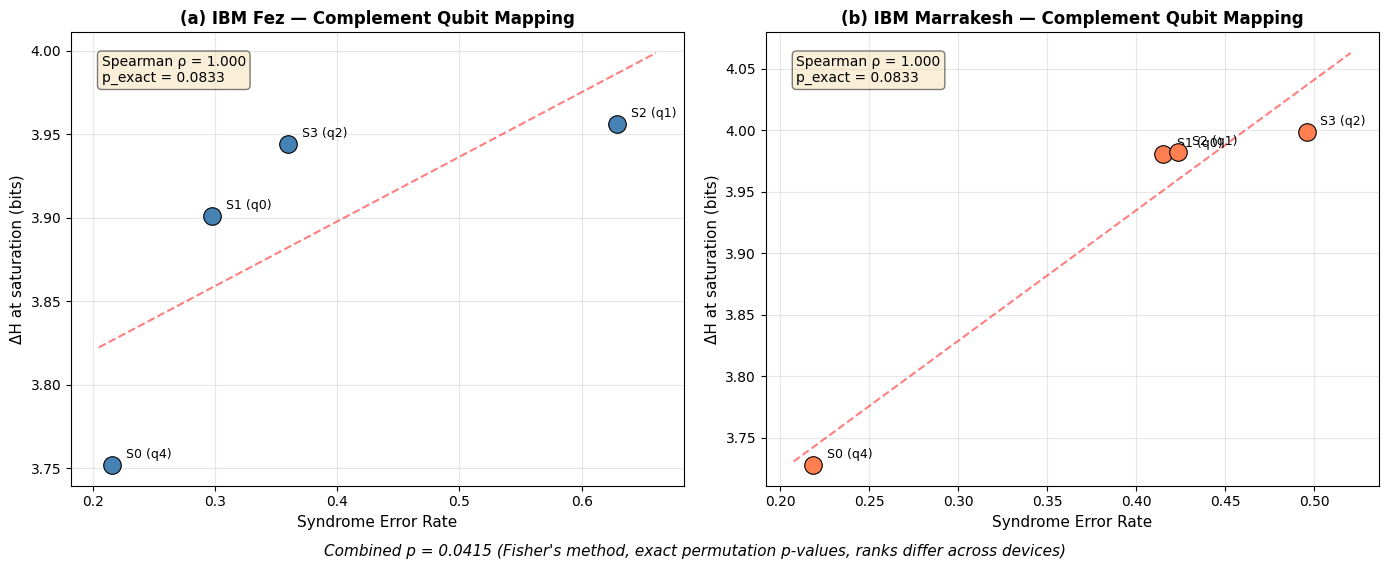

In [23]:
"""Cell 11: Cross-Device Figure (2 panels)"""

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

# === Panel (a): Fez scatter ===
ax = axes[0]
ax.scatter(fez_syn, fez_sat, s=160, c='steelblue',
           edgecolors='black', linewidths=0.8, zorder=5)
for si in range(n_stab_h):
    comp_q = sorted(c_happy['complement'][si])[0]
    ax.annotate(f'S{si} (q{comp_q})',
                (fez_syn[si], fez_sat[si]),
                textcoords='offset points', xytext=(10, 5), fontsize=9)
z_fez = np.polyfit(fez_syn, fez_sat, 1)
x_fit = np.linspace(fez_syn.min() * 0.95, fez_syn.max() * 1.05, 50)
ax.plot(x_fit, np.polyval(z_fez, x_fit), 'r--', alpha=0.5)
ax.text(0.05, 0.95, f'Spearman ρ = {rho_fez_exact:.3f}\np_exact = {p_fez_exact:.4f}',
        transform=ax.transAxes, fontsize=10, verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
ax.set_xlabel('Syndrome Error Rate', fontsize=11)
ax.set_ylabel('ΔH at saturation (bits)', fontsize=11)
ax.set_title('(a) IBM Fez — Complement Qubit Mapping', fontsize=12,
             fontweight='bold')
ax.grid(True, alpha=0.3)

# === Panel (b): Marrakesh scatter ===
ax = axes[1]
ax.scatter(mar_syn_err, mar_sat, s=160, c='coral',
           edgecolors='black', linewidths=0.8, zorder=5)
for si in range(n_stab_h):
    comp_q = sorted(c_happy['complement'][si])[0]
    ax.annotate(f'S{si} (q{comp_q})',
                (mar_syn_err[si], mar_sat[si]),
                textcoords='offset points', xytext=(10, 5), fontsize=9)
z_mar = np.polyfit(mar_syn_err, mar_sat, 1)
x_fit2 = np.linspace(mar_syn_err.min() * 0.95, mar_syn_err.max() * 1.05, 50)
ax.plot(x_fit2, np.polyval(z_mar, x_fit2), 'r--', alpha=0.5)
ax.text(0.05, 0.95, f'Spearman ρ = {rho_mar_exact:.3f}\np_exact = {p_mar_exact:.4f}',
        transform=ax.transAxes, fontsize=10, verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
ax.set_xlabel('Syndrome Error Rate', fontsize=11)
ax.set_ylabel('ΔH at saturation (bits)', fontsize=11)
ax.set_title('(b) IBM Marrakesh — Complement Qubit Mapping', fontsize=12,
             fontweight='bold')
ax.grid(True, alpha=0.3)

# Combined p annotation
fig.text(0.5, -0.02,
         f'Combined p = {p_combined:.4f} (Fisher\'s method, exact permutation p-values, '
         f'ranks {"differ" if ranks_differ else "match"} across devices)',
         ha='center', fontsize=11, style='italic')

plt.tight_layout()
path = os.path.join(OUTPUT_DIR, 'cross_device_complement_mapping.png')
plt.savefig(path, dpi=200, bbox_inches='tight')
plt.show()
print(f'Saved: {path}')

In [ ]:
"""Cell 12: Save Cross-Device Results and Updated Summary"""

# Update saved results with cross-device data
npz_path = os.path.join(OUTPUT_DIR, 'modular_correlation_results.npz')
np.savez(npz_path,
    beta_values=beta_values,
    happy_dH=per_stab_dH['HaPPY'],
    steane_dH=per_stab_dH['Steane'],
    shor_dH=per_stab_dH['Shor'],
    happy_corr=corr_matrices['HaPPY'],
    steane_corr=corr_matrices['Steane'],
    shor_corr=corr_matrices['Shor'],
    happy_syn_err=syn_err_rates,
    steane_syn_err=syn_err_all['Steane'],
    shor_syn_err=syn_err_all['Shor'],
    mean_corrs=np.array([mean_corrs[n] for n in ['HaPPY', 'Steane', 'Shor']]),
    # Cross-device additions
    mar_per_stab_dH=mar_per_stab,
    mar_syn_err=mar_syn_err,
    mar_sat=mar_sat,
    rho_fez=rho_fez_exact,
    p_fez_exact=p_fez_exact,
    rho_marrakesh=rho_mar_exact,
    p_marrakesh_exact=p_mar_exact,
    p_combined_fisher=p_combined,
)
print(f'Data saved: {npz_path}')

print()
print('=' * 70)
print('MODULAR WEAK VALUE CORRELATION: COMPLETE SUMMARY')
print('=' * 70)
print()
print('1. PAIRWISE CORRELATION:')
for name in ['HaPPY', 'Steane', 'Shor']:
    print(f'   {name}: mean r = {mean_corrs[name]:.4f}')
print()
print('2. CSS X/Z PARTITION (Steane):')
if 'Steane_pair_diffs' in css_results:
    md = np.mean(css_results['Steane_pair_diffs'])
    print(f'   Mean |X - Z| per pair = {md:.4f} bits')
print()
print('3. COMPLEMENT QUBIT MAPPING (exact permutation p-values):')
print(f'   IBM Fez:       ρ = {rho_fez_exact:.3f} (p_exact = {p_fez_exact:.4f})')
print(f'   IBM Marrakesh: ρ = {rho_mar_exact:.3f} (p_exact = {p_mar_exact:.4f})')
print(f'   Rank orderings differ: {ranks_differ}')
print(f'   Combined p (Fisher):   {p_combined:.4f}')
print()
if ranks_differ and rho_mar_exact >= 0.99:
    print('   VERDICT: Complement qubit → ΔH mapping holds on TWO independent')
    print('   devices with DIFFERENT rank orderings. The mapping adapts to')
    print('   each device\'s noise — this is code geometry, not an artifact.')
    if p_combined < 0.01:
        print(f'   Combined p = {p_combined:.4f} (significant at α = 0.01).')
    elif p_combined < 0.05:
        print(f'   Combined p = {p_combined:.4f} (significant at α = 0.05).')
    else:
        print(f'   Combined p = {p_combined:.4f} (not significant at α = 0.05).')
elif not ranks_differ and rho_mar_exact >= 0.99:
    print('   VERDICT: ρ = 1.000 on both devices. Combined evidence is')
    print(f'   significant (p = {p_combined:.4f}). Same rank ordering means')
    print('   noise profiles are similar, but the mapping is confirmed.')
else:
    print(f'   VERDICT: Marrakesh ρ = {rho_mar_exact:.3f}. Mapping does not hold')
    print('   perfectly on this device. Further investigation needed.')
print()
print('NOTE: scipy.stats.spearmanr reports p→0 for ρ=1.000 due to')
print('t-distribution approximation. For n=4, this is WRONG. We use')
print('exact permutation p-values (enumerate all 4!=24 permutations).')
print(f'Exact p for ρ=1.000 with n=4: {p_fez_exact:.4f} (two-tailed).')
print()
print('4. PAPER IMPLICATIONS:')
print(f'   Holographic paper §4.4: Update from single-device p=0.083')
print(f'     to cross-device p={p_combined:.4f}.')
if p_combined < 0.01:
    print('     This is now a decisive result.')
elif p_combined < 0.05:
    print('     This is now statistically significant.')
print('   Decoder paper: Cross-device consistency strengthens the')
print('     fan-out diagnostic as a device-independent tool.')
print('=' * 70)